# Домашнє завдання №5 — Частина 2

## Аналіз результатів опитування українських розробників (червень 2017)

Джерело даних: [репозиторій DOU `devua/csv`](https://github.com/devua/csv/tree/master/salaries).

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.max_columns", None)
print(f"Pandas version: {pd.__version__}")

Pandas version: 3.0.1


## 1–2. Читання CSV та перші рядки

In [2]:
df = pd.read_csv("2017_jun_final.csv")
df.head()

,N,Должность,Язык.программирования,Специализация,Общий.опыт.работы,Опыт.работы.на.текущем.месте,Зарплата.в.месяц,Изменение.зарплаты.за.12.месяцев,Город,Размер.компании,Тип.компании,Пол,Возраст,Образование,Университет,Еще.студент,Уровень.английского,Предметная.область,Дата.заполнения,User.Agent,exp,current_job_exp,salary,Валюта,cls
0,1,Junior QA engineer,NaN,Manual QA,0.5,0.5,400,0,Харьков,до 10 человек,Аутсорсинговая,женский,20,Незаконченное высшее,ХНЭУ,True,ниже среднего,"iOS,eCommerce",12/06/2017 12:38:08,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,0.5,0.5,400,NaN,QA
1,2,Junior QA engineer,NaN,Manual QA,меньше 3 месяцев,меньше 3 месяцев,430,130,Харьков,свыше 1000 человек,Аутсорсинговая,женский,21,Незаконченное высшее,ХНЭУ,True,выше среднего,Веб-разработка,12/06/2017 12:42:51,Mozilla/5.0 (iPad; CPU OS 10_2_1 like Mac OS X...,0.0,0.0,430,NaN,QA
2,3,Software Engineer,C#/.NET,NaN,4,1,2500,800,Киев,до 1000 человек,Аутсорсинговая,мужской,26,Высшее,ДонНТУ,False,средний,"Веб-разработка,Корпоративные системы",12/06/2017 13:02:47,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,4.0,1.0,2500,NaN,DEV
3,4,Software Engineer,JavaScript,NaN,5,4,2000,400,Одесса,до 200 человек,Продуктовая,мужской,30,Среднее,NaN,False,ниже среднего,"Desktop Applications,Веб-разработка",12/06/2017 13:03:01,Mozilla/5.0 (Windows NT 6.1; Win64; x64) Apple...,5.0,4.0,2000,NaN,DEV
4,5,Senior Software Engineer,JavaScript,NaN,10 и более лет,0.5,4500,500,Другой,до 10 человек,Продуктовая,мужской,30,Техникум / Колледж,NaN,False,средний,"Desktop Applications,Веб-разработка",12/06/2017 13:03:47,Mozilla/5.0 (iPhone; CPU iPhone OS 10_3_2 like...,10.0,0.5,4500,NaN,DEV


## 3. Розмір таблиці

In [3]:
print(f"Розмір таблиці: {df.shape}")
print(f"Рядків: {df.shape[0]}, стовпців: {df.shape[1]}")

Розмір таблиці: (8704, 25)
Рядків: 8704, стовпців: 25


## 4. Типи всіх стовпців

In [4]:
df.dtypes

N                                     int64
Должность                               str
Язык.программирования                   str
Специализация                           str
Общий.опыт.работы                       str
Опыт.работы.на.текущем.месте            str
Зарплата.в.месяц                      int64
Изменение.зарплаты.за.12.месяцев      int64
Город                                   str
Размер.компании                         str
Тип.компании                            str
Пол                                     str
Возраст                               int64
Образование                             str
Университет                             str
Еще.студент                            bool
Уровень.английского                     str
Предметная.область                      str
Дата.заполнения                         str
User.Agent                              str
exp                                 float64
current_job_exp                     float64
salary                          

## 5. Частка пропусків у кожній колонці

In [5]:
missing_share = (df.isnull().sum() / len(df)).sort_values(ascending=False)
missing_share.rename("Частка пропусків").to_frame()

,Частка пропусків
Валюта,0.998851
Специализация,0.829389
Язык.программирования,0.442325
cls,0.180836
Университет,0.041131
Предметная.область,0.025620
N,0.000000
Должность,0.000000
Общий.опыт.работы,0.000000
Город,0.000000


## 6. Видалення стовпців із пропусками, крім `Язык.программирования`

In [6]:
language_column = "Язык.программирования"
columns_with_missing = df.columns[df.isnull().any()]
columns_to_drop = columns_with_missing.drop(language_column)
df_reduced = df.drop(columns=columns_to_drop).copy()
print("Видалено стовпців:", len(columns_to_drop))
print("Залишилося стовпців:", df_reduced.shape[1])
print(df_reduced.columns.tolist())

Видалено стовпців: 5
Залишилося стовпців: 20
['N', 'Должность', 'Язык.программирования', 'Общий.опыт.работы', 'Опыт.работы.на.текущем.месте', 'Зарплата.в.месяц', 'Изменение.зарплаты.за.12.месяцев', 'Город', 'Размер.компании', 'Тип.компании', 'Пол', 'Возраст', 'Образование', 'Еще.студент', 'Уровень.английского', 'Дата.заполнения', 'User.Agent', 'exp', 'current_job_exp', 'salary']


## 7. Повторна перевірка частки пропусків

In [7]:
missing_after_drop = df_reduced.isnull().sum() / len(df_reduced)
print("Стовпці, у яких залишилися пропуски:")
missing_after_drop[missing_after_drop > 0].rename("Частка пропусків").to_frame()

Стовпці, у яких залишилися пропуски:


,Частка пропусків
Язык.программирования,0.442325


## 8–9. Видалення рядків із пропусками та новий розмір

In [8]:
df_clean = df_reduced.dropna().copy()
print(f"Розмір після dropna: {df_clean.shape}")
print("Залишилося пропусків:", int(df_clean.isnull().sum().sum()))

Розмір після dropna: (4854, 20)
Залишилося пропусків: 0


## 10–11. Таблиця `python_data`

In [9]:
python_data = df_clean[df_clean[language_column] == "Python"].copy()
print(f"Розмір python_data: {python_data.shape}")
python_data.head()

Розмір python_data: (207, 20)


,N,Должность,Язык.программирования,Общий.опыт.работы,Опыт.работы.на.текущем.месте,Зарплата.в.месяц,Изменение.зарплаты.за.12.месяцев,Город,Размер.компании,Тип.компании,Пол,Возраст,Образование,Еще.студент,Уровень.английского,Дата.заполнения,User.Agent,exp,current_job_exp,salary
12,13,Software Engineer,Python,1,меньше 3 месяцев,800,200,Киев,до 50 человек,Аутсорсинговая,мужской,26,Высшее,False,ниже среднего,12/06/2017 13:05:54,Mozilla/5.0 (Windows NT 6.1; Win64; x64) Apple...,1.0,0.0,800
68,69,Software Engineer,Python,1.5,0.5,900,900,Киев,до 10 человек,Стартап,мужской,21,Незаконченное высшее,True,выше среднего,12/06/2017 13:11:17,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1.5,0.5,900
87,88,Junior Software Engineer,Python,0.5,0.5,600,0,Киев,до 10 человек,Аутсорсинговая,мужской,19,Незаконченное высшее,True,выше среднего,12/06/2017 13:12:25,Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/53...,0.5,0.5,600
114,115,Junior Software Engineer,Python,1.5,0.5,685,250,Киев,до 1000 человек,Аутсорсинговая,мужской,21,Незаконченное высшее,False,средний,12/06/2017 13:14:52,Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/53...,1.5,0.5,685
143,144,Junior Software Engineer,Python,1,1,750,250,Киев,до 10 человек,Аутсорсинговая,мужской,21,Незаконченное высшее,True,выше среднего,12/06/2017 13:19:10,Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/53...,1.0,1.0,750


## 12. Групування Python-спеціалістів за посадою

In [10]:
grouped_by_position = python_data.groupby("Должность")
print("Кількість груп:", grouped_by_position.ngroups)
grouped_by_position.size().sort_values(ascending=False).rename("Кількість").to_frame()

Кількість груп: 5


,Кількість
Должность,
Software Engineer,100
Junior Software Engineer,63
Senior Software Engineer,31
Technical Lead,11
System Architect,2


## 13. Мінімальна та максимальна зарплата за посадою

In [11]:
salary_by_position = grouped_by_position["Зарплата.в.месяц"].agg(["min", "max"])
salary_by_position

,min,max
Должность,,
Junior Software Engineer,100,1250
Senior Software Engineer,1300,9200
Software Engineer,500,5400
System Architect,3000,5000
Technical Lead,1425,6200


## 14. Функція `fill_avg_salary` і стовпчик `avg`

In [12]:
def fill_avg_salary(row):
    return row[["min", "max"]].mean()

salary_by_position["avg"] = salary_by_position.apply(fill_avg_salary, axis=1)
salary_by_position

,min,max,avg
Должность,,,
Junior Software Engineer,100,1250,675.0
Senior Software Engineer,1300,9200,5250.0
Software Engineer,500,5400,2950.0
System Architect,3000,5000,4000.0
Technical Lead,1425,6200,3812.5


## 15. Описова статистика нового стовпчика `avg`

In [13]:
salary_by_position["avg"].describe()

count       5.000000
mean     3337.500000
std      1700.091909
min       675.000000
25%      2950.000000
50%      3812.500000
75%      4000.000000
max      5250.000000
Name: avg, dtype: float64

## 16. Збереження отриманої таблиці у CSV

In [14]:
output_file = "python_salary_by_position.csv"
salary_by_position.to_csv(output_file, encoding="utf-8-sig")
print(f"Таблицю збережено у файл: {output_file}")

Таблицю збережено у файл: python_salary_by_position.csv


## Візуалізація 1. Найпопулярніші мови програмування

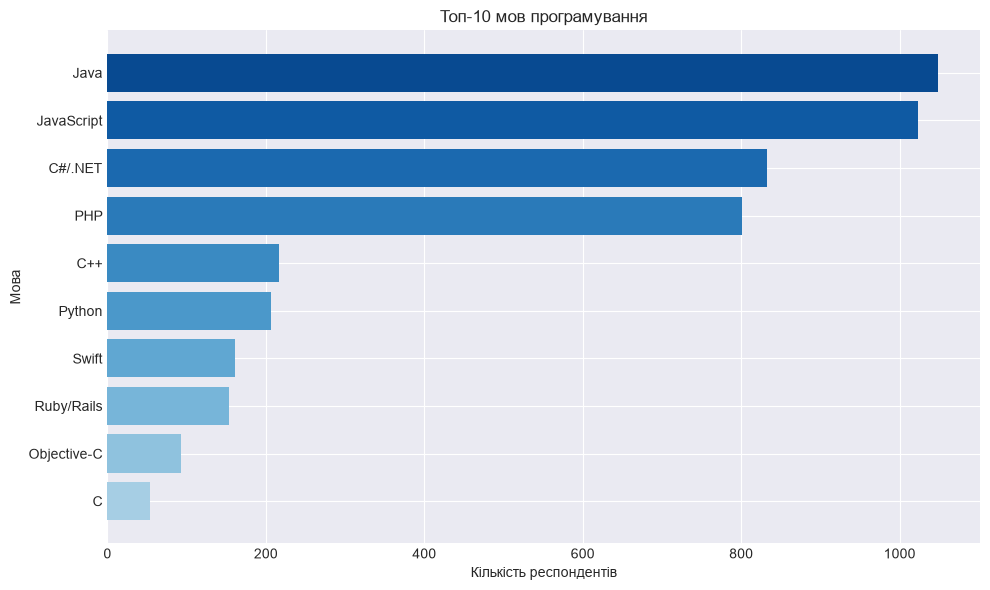

In [15]:
top_languages = df[language_column].value_counts().head(10).sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_languages.index, top_languages.values, color=plt.cm.Blues(np.linspace(0.35, 0.9, len(top_languages))))
ax.set(title="Топ-10 мов програмування", xlabel="Кількість респондентів", ylabel="Мова")
plt.tight_layout()
plt.show()

## Візуалізація 2. Розподіл місячних зарплат

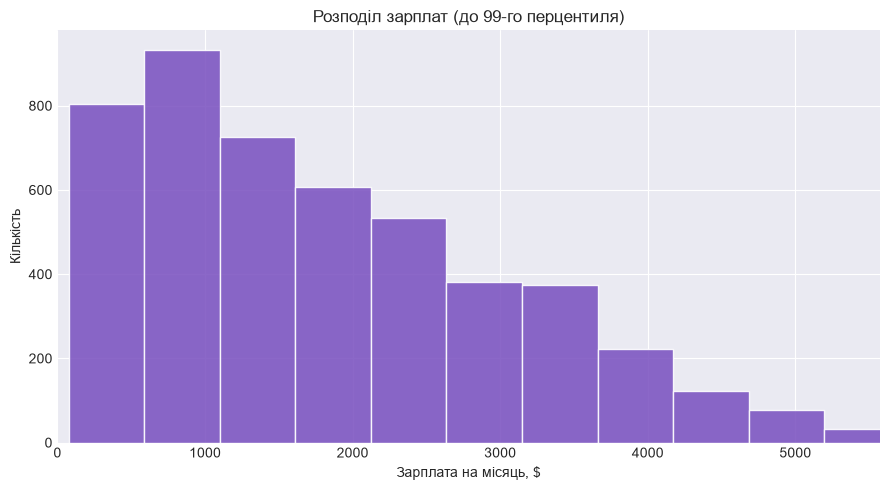

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df_clean["Зарплата.в.месяц"], bins=35, color="#7E57C2", edgecolor="white", alpha=0.9)
ax.set_xlim(0, df_clean["Зарплата.в.месяц"].quantile(0.99))
ax.set(title="Розподіл зарплат (до 99-го перцентиля)", xlabel="Зарплата на місяць, $", ylabel="Кількість")
plt.tight_layout()
plt.show()

## Візуалізація 3. Python-спеціалісти за містами

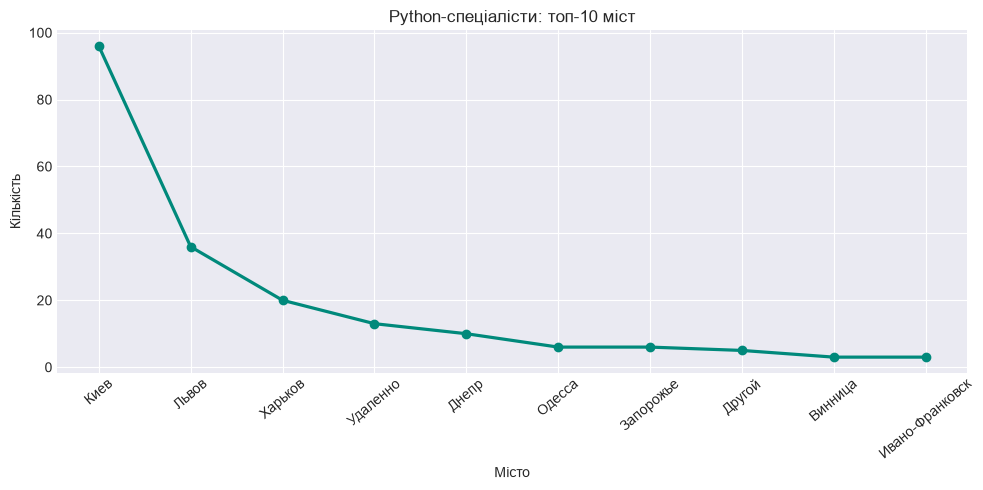

In [17]:
python_cities = python_data["Город"].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(python_cities.index, python_cities.values, marker="o", linewidth=2.3, color="#00897B")
ax.set(title="Python-спеціалісти: топ-10 міст", xlabel="Місто", ylabel="Кількість")
ax.tick_params(axis="x", rotation=40)
plt.tight_layout()
plt.show()

## Візуалізація 4. Зарплатні межі Python-спеціалістів за посадами

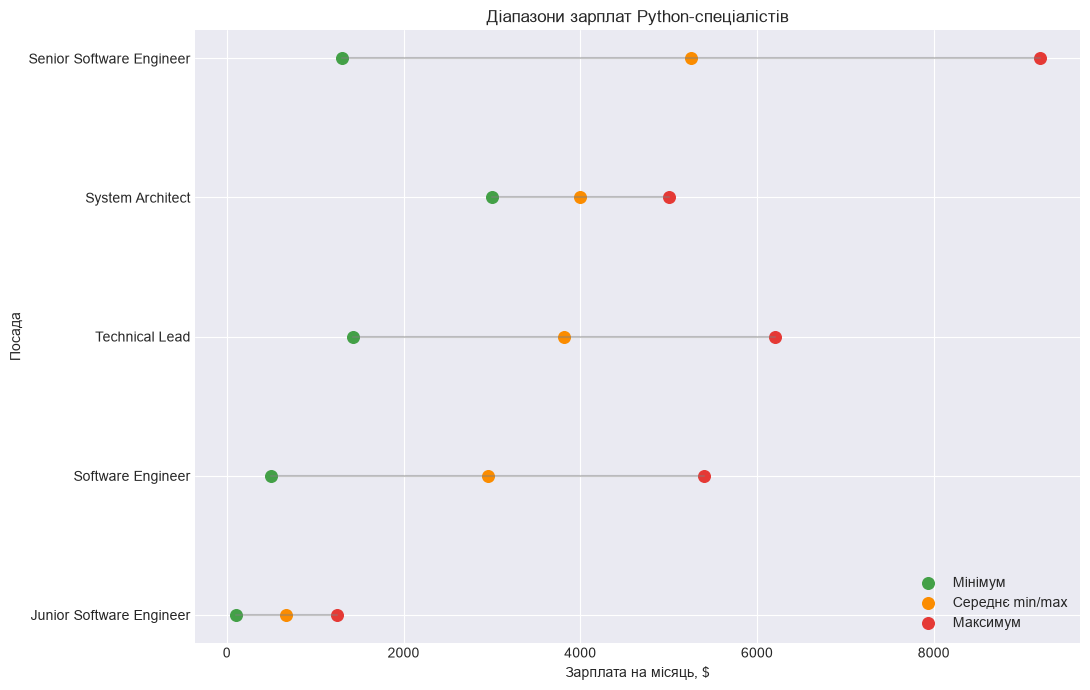

In [18]:
salary_plot = salary_by_position.sort_values("avg")
fig, ax = plt.subplots(figsize=(11, 7))
positions = np.arange(len(salary_plot))
ax.scatter(salary_plot["min"], positions, label="Мінімум", s=70, color="#43A047")
ax.scatter(salary_plot["avg"], positions, label="Середнє min/max", s=70, color="#FB8C00")
ax.scatter(salary_plot["max"], positions, label="Максимум", s=70, color="#E53935")
for y, low, high in zip(positions, salary_plot["min"], salary_plot["max"]):
    ax.plot([low, high], [y, y], color="gray", alpha=0.45)
ax.set_yticks(positions, salary_plot.index)
ax.set(title="Діапазони зарплат Python-спеціалістів", xlabel="Зарплата на місяць, $", ylabel="Посада")
ax.legend()
plt.tight_layout()
plt.show()